In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

In [3]:
import pandas as pd

df = pd.read_csv("GlobalWeatherRepository .csv")

In [4]:
def preprocess(df):
    df = df.copy()

    # Convert datetime
    df['last_updated'] = pd.to_datetime(df['last_updated'])

    # Remove duplicates
    df.drop_duplicates(inplace=True)

    # Fill missing values using median (robust)
    for col in ['temperature_celsius','humidity','wind_kph','precip_mm']:
        df[col] = df.groupby('country')[col].transform(lambda x: x.fillna(x.median()))

    return df

df = preprocess(df)

In [11]:
df.to_csv("cleaned_weather_data.csv", index=False)

In [5]:
df['year'] = df['last_updated'].dt.year
df['month'] = df['last_updated'].dt.month
df['day'] = df['last_updated'].dt.day

# Season
def get_season(m):
    return ['Winter','Winter','Summer','Summer','Summer','Monsoon','Monsoon','Monsoon','Autumn','Autumn','Winter','Winter'][m-1]

df['season'] = df['month'].apply(get_season)

# Advanced features
df['heat_index'] = df['temperature_celsius'] + (0.33 * df['humidity']) - 4

df['instability_index'] = (
    df['wind_kph'] * 0.4 +
    df['precip_mm'] * 0.4 +
    (100 - df['humidity']) * 0.2
)

# Rolling trends
df = df.sort_values('last_updated')
df['temp_7d_avg'] = df['temperature_celsius'].rolling(7).mean()

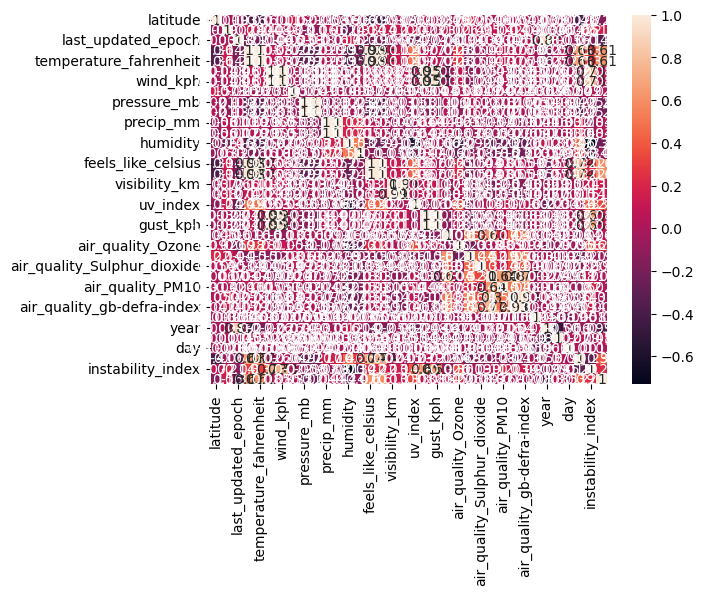

In [6]:
sns.heatmap(df.corr(numeric_only=True), annot=True)
plt.show()

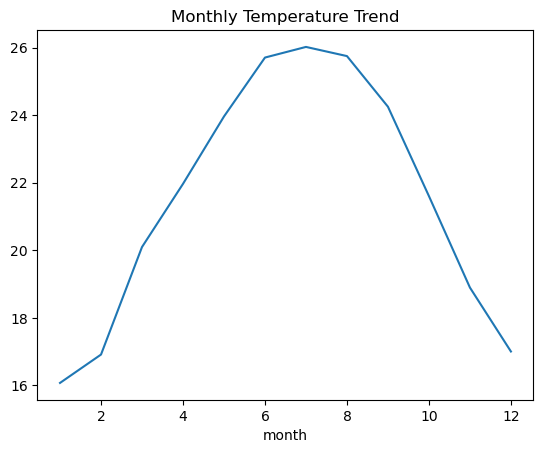

In [7]:
df.groupby('month')['temperature_celsius'].mean().plot(title="Monthly Temperature Trend")
plt.show()

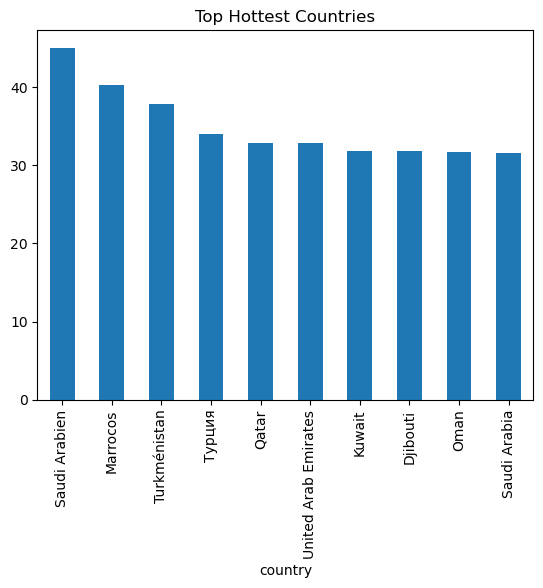

In [8]:
df.groupby('country')['temperature_celsius'].mean().sort_values(ascending=False).head(10).plot(kind='bar')
plt.title("Top Hottest Countries")
plt.show()

In [9]:
q_high = df['temperature_celsius'].quantile(0.99)
q_low = df['temperature_celsius'].quantile(0.01)

extreme = df[(df['temperature_celsius'] > q_high) | (df['temperature_celsius'] < q_low)]

In [10]:
features = df[['temperature_celsius','humidity','wind_kph','precip_mm']].dropna()

scaled = StandardScaler().fit_transform(features)

kmeans = KMeans(n_clusters=4, random_state=42)
df.loc[features.index, 'cluster'] = kmeans.fit_predict(scaled)

In [12]:
import os
print(os.getcwd())

c:\Users\Akash\Desktop\weather analysis infosys


Seasonal Temperature Distribution

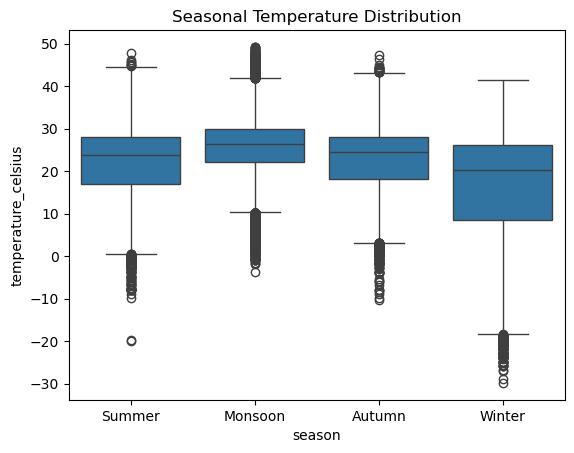

In [13]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(x='season', y='temperature_celsius', data=df)
plt.title("Seasonal Temperature Distribution")
plt.show()

Rainfall Intensity Distribution

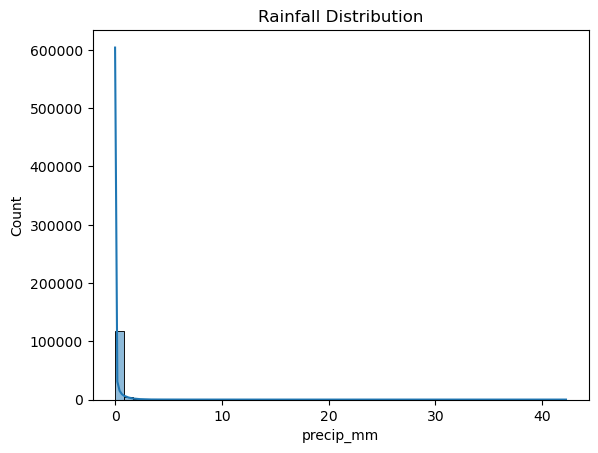

In [14]:
sns.histplot(df['precip_mm'], bins=50, kde=True)
plt.title("Rainfall Distribution")
plt.show()

Most days → low rain

Few extreme events → heavy rain

Country-wise Heatmap

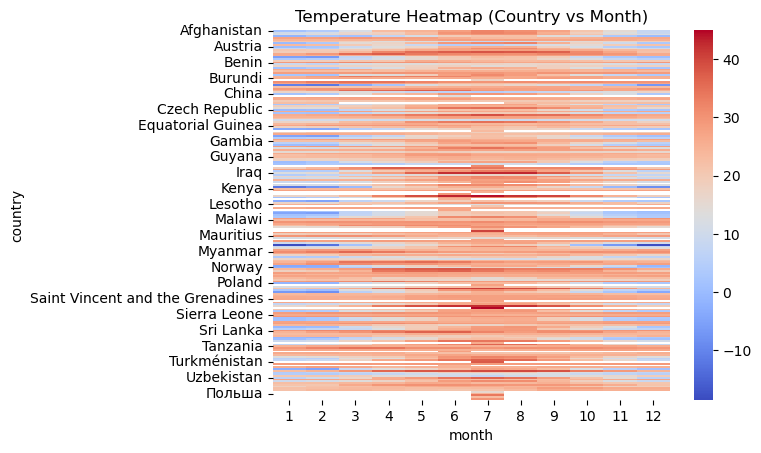

In [15]:
pivot = df.pivot_table(values='temperature_celsius', index='country', columns='month')

sns.heatmap(pivot, cmap='coolwarm')
plt.title("Temperature Heatmap (Country vs Month)")
plt.show()

Insight:

Seasonal patterns across countries

Easy comparison

Temperature vs Humidity

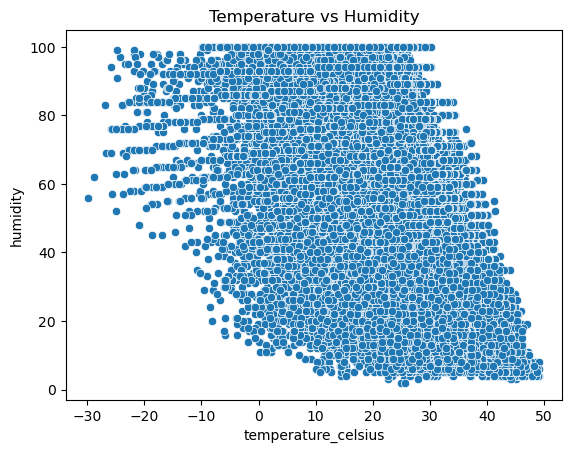

In [16]:
sns.scatterplot(x='temperature_celsius', y='humidity', data=df)
plt.title("Temperature vs Humidity")
plt.show()

Insight:

Shows inverse or clustered relationship

Extreme Events Highlight

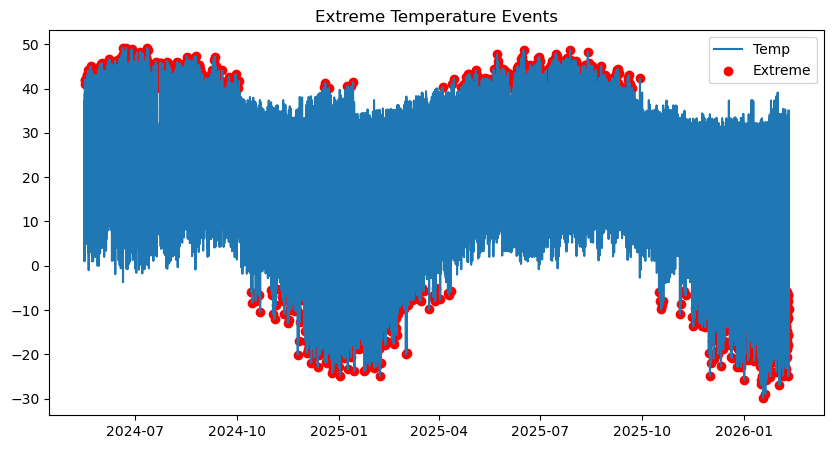

In [19]:
plt.figure(figsize=(10,5))

plt.plot(df['last_updated'], df['temperature_celsius'], label='Temp')

plt.scatter(extreme['last_updated'], extreme['temperature_celsius'], 
            color='red', label='Extreme')

plt.legend()
plt.title("Extreme Temperature Events")
plt.show()

Insight:

Clearly shows anomalies → big marks

Climate Clusters Visualization

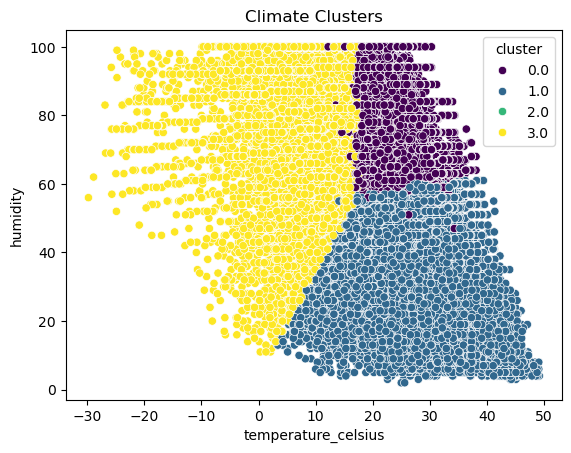

In [20]:
sns.scatterplot(
    x='temperature_celsius', 
    y='humidity', 
    hue='cluster', 
    data=df,
    palette='viridis'
)

plt.title("Climate Clusters")
plt.show()

Insight:

Different climate zones visible

Rolling Trend

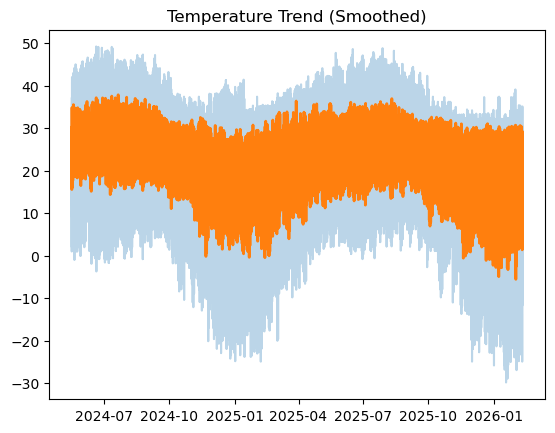

In [21]:
plt.plot(df['last_updated'], df['temperature_celsius'], alpha=0.3)
plt.plot(df['last_updated'], df['temp_7d_avg'], linewidth=2)

plt.title("Temperature Trend (Smoothed)")
plt.show()

Insight:

Noise removed

Trend clearly visible

CHOROPLETH MAP

In [22]:
import plotly.express as px

# Country-wise average temperature
country_temp = df.groupby('country')['temperature_celsius'].mean().reset_index()

fig = px.choropleth(
    country_temp,
    locations='country',
    locationmode='country names',
    color='temperature_celsius',
    color_continuous_scale='RdYlBu_r',
    title='Global Temperature Distribution'
)

fig.show()

A choropleth map was used to visualize global temperature distribution across countries, enabling intuitive geographic comparison of climate patterns

RAINFALL MAP

In [23]:
country_rain = df.groupby('country')['precip_mm'].mean().reset_index()

fig = px.choropleth(
    country_rain,
    locations='country',
    locationmode='country names',
    color='precip_mm',
    color_continuous_scale='Blues',
    title='Global Rainfall Distribution'
)

fig.show()

In [24]:
year_temp = df.groupby(['year','country'])['temperature_celsius'].mean().reset_index()

fig = px.choropleth(
    year_temp,
    locations='country',
    locationmode='country names',
    color='temperature_celsius',
    animation_frame='year',
    color_continuous_scale='RdYlBu_r',
    title='Temperature Change Over Time'
)

fig.show()